In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

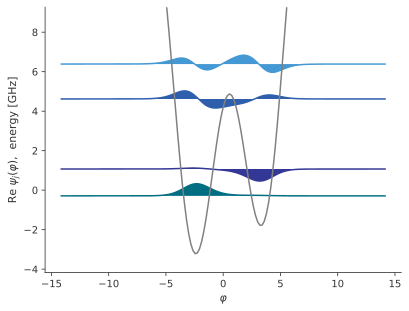

In [26]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=12)

fluxonium2 =  scqubits.Fluxonium(EJ=4.8,
                        EC=4/4,
                        EL=4/8,
                        flux=0.42,cutoff=110,
                        truncated_dim=12)


system = FluxoniumFluxoniumSystem(
    fluxonium1  = fluxonium1,
    fluxonium2 = fluxonium2,
    computaional_states = '1,2',
    g_strength = 0.2,
    )

fluxonium2.plot_wavefunction(which=[0,1,2,3])


In [27]:
system.evals[system.product_to_dressed[(0,3)]]-system.evals[system.product_to_dressed[(0,2)]], \
system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]], \
system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]]

(1.7688871392995864, 1.7512013655075922, 1.7709471725872419)

# Let's try EIT

In [28]:
initial_states = [
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
]

e_ops = []
for ql in range(3):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

# Get the Raman pi pulse parameters
op = system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)



length = 200


aera_probe = np.pi  * 0.3
amplitude_g02 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,0)]])   )
amplitude_g21 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,1)]])   )

amplitude_e02 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,0)]])   )
amplitude_e21 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,1)]])   )

amplitude_f02 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,0)]])   )
amplitude_f21 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,1)]])   )

amplitude_g02, amplitude_g21,     amplitude_e02, amplitude_e21,     amplitude_f02, amplitude_f21

(0.009782097503083622,
 0.015693177341790387,
 0.010515228965887656,
 0.017291786666593492,
 0.009829882041095325,
 0.01587529258701537)

# This is a Raman drive without EIT (can be updated to STIRAP)

 Total run time:  11.76s*] Elapsed 11.76s / Remaining 00:00:00:00[*********40%           ] Elapsed 0.30s / Remaining 00:00:00:00
 Total run time:  11.78s*] Elapsed 11.78s / Remaining 00:00:00:00
 Total run time:  12.41s*] Elapsed 12.41s / Remaining 00:00:00:00


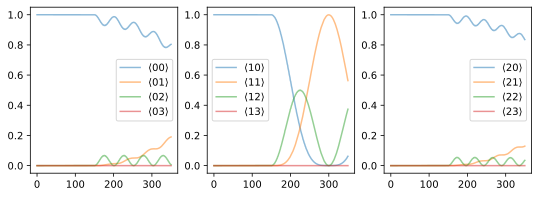

In [29]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0
results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_e02,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,1)]] + Delta/(2*np.pi),
                    'amp2': amplitude_e21,
                    't_rise2': 1e-5,
                    't_square2': 1000,
                    't_start2': 150
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

# Can I darken two transitions?

 Total run time:  39.11s*] Elapsed 39.11s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 Total run time:  39.51s*] Elapsed 39.51s / Remaining 00:00:00:00
 Total run time:  39.52s*] Elapsed 39.52s / Remaining 00:00:00:00


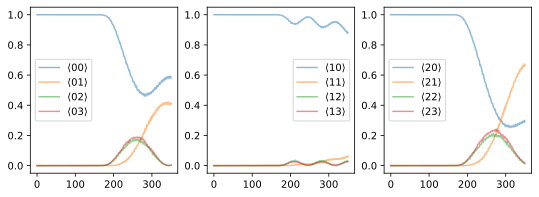

In [34]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0

results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # EIT drive 1 
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(0,3)]]-system.evals[system.product_to_dressed[(0,2)]] - Delta/(2*np.pi),
                    'amp': 0.1,
                    't_rise':  100,
                    't_square': 1000,
                    't_start': 0
                  },
                ),

            # EIT drive 2
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=forth_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d3':system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]] - Delta/(2*np.pi),
                    'amp3': 0.0,
                    't_rise3':  100,
                    't_square3': 1000,
                    't_start3': 0
                  },
                ),

            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_e02,
                    't_rise1': 50,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,1)]] + Delta/(2*np.pi),
                    'amp2': amplitude_e21,
                    't_rise2': 50,
                    't_square2': 1000,
                    't_start2': 150
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

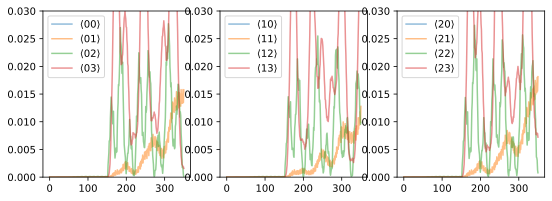

In [20]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(0,0.03)


# Let's consider what's the effect of the coupling on the gf-IFQ

$ A \cos(x) + B \cos(y) = (A + B) \cos\left(\frac{{x + y}}{2}\right) \cos\left(\frac{{x - y}}{2}\right) + (B - A) \sin\left(\frac{{x + y}}{2}\right) \sin\left(\frac{{x - y}}{2}\right)$

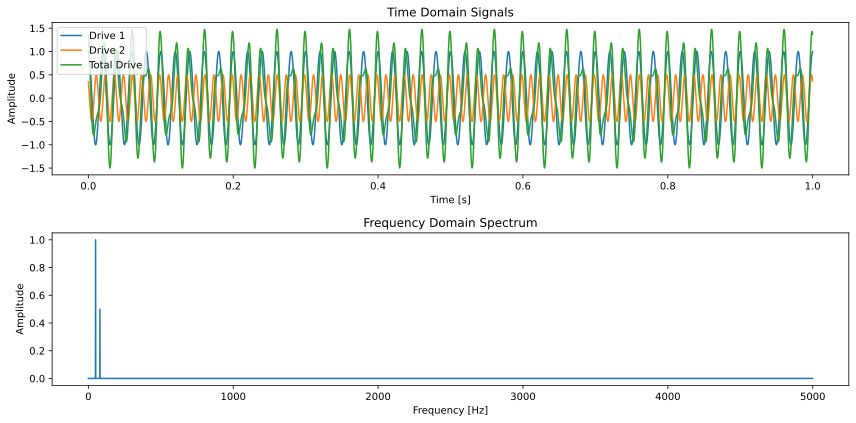

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Define the sampling parameters
sampling_rate = 10000  # Sampling rate in Hz
T = 1.0 / sampling_rate  # Sampling interval
duration = 1.0  # Duration in seconds
t = np.arange(0, duration, T)  # Time vector

# Define the drive frequencies and phases
omega_1 = 2 * np.pi * 50  # Drive frequency 1 in Hz
omega_2 = 2 * np.pi * 80  # Drive frequency 2 in Hz
phi_1 = 0  # Phase 1
phi_2 = np.pi / 4  # Phase 2

# Define the drive amplitudes
A = 1.0
B = 0.5

# Create the signals
V1 = A * np.cos(omega_1 * t + phi_1)
V2 = B * np.cos(omega_2 * t + phi_2)
V_total = V1 + V2

# Perform the FFT
N = len(t)
yf = fft(V_total)
xf = fftfreq(N, T)[:N//2]

# Plot the time domain signals
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, V1, label='Drive 1')
plt.plot(t, V2, label='Drive 2')
plt.plot(t, V_total, label='Total Drive')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Time Domain Signals')

# Plot the frequency domain signals
plt.subplot(2, 1, 2)
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Spectrum')

plt.tight_layout()
plt.show()
